# Multi-Armed Bandit Recommender

## Data preparation

In [ ]:
from recsys_common import *

configure_notebook()

project_dir = Path.cwd()
shared_dir = project_dir / "artifacts" / "shared"

required_shared = [
    shared_dir / "df_model.csv",
    shared_dir / "train_df.csv",
    shared_dir / "test_df.csv",
]
missing_shared = [str(p) for p in required_shared if not p.exists()]
if missing_shared:
    raise FileNotFoundError(
        "Shared artifacts are required. Run 0_Data_Exploration.ipynb first. Missing:\n"
        + "\n".join(missing_shared)
    )

print("Loading prepared data from artifacts/shared/")
df_model = pd.read_csv(shared_dir / "df_model.csv")
train_df = pd.read_csv(shared_dir / "train_df.csv")
test_df = pd.read_csv(shared_dir / "test_df.csv")

for frame in (df_model, train_df, test_df):
    if "review_time" in frame.columns:
        frame["review_time"] = pd.to_datetime(frame["review_time"], errors="coerce")

# Binary reward for bandit feedback simulation.
relevance_threshold = 4
for frame in (train_df, test_df):
    frame["is_relevant"] = (frame["Score"] >= relevance_threshold).astype(int)

print(f"Shared df_model: {df_model.shape}")
print(f"Shared train_df: {train_df.shape}")
print(f"Shared test_df: {test_df.shape}")
print("Train relevant rate:", round(train_df["is_relevant"].mean(), 4))

## MAB Framework

In a Multi-Armed Bandit recommender, each product is an arm with a Beta(α, β) distribution representing our belief about its "like probability." The system selects an arm via a policy, observes the user's reaction (reward), and updates that arm's distribution accordingly.

Values of α are counts of positive rewards, while values of β are counts of negative rewards.

An important concept in MAB is exploration vs. exploitation: recommending what we *think* is best (exploit) vs. trying uncertain options to learn more (explore). Each policy balances this differently.

In [2]:
class MABRecommender:
    def __init__(self, product_ids):
        self.arms = {pid: [1, 1] for pid in product_ids}  # Beta(α=1, β=1) prior
        self.total_pulls = 0

    def select_arm(self):
        raise NotImplementedError

    def update(self, product_id, reward):
        if reward == 1:
            self.arms[product_id][0] += 1
        else:
            self.arms[product_id][1] += 1
        self.total_pulls += 1

    def expected_reward(self, product_id):
        a, b = self.arms[product_id]
        return a / (a + b)


class EpsilonGreedy(MABRecommender):
    def __init__(self, product_ids, epsilon=0.1):
        super().__init__(product_ids)
        self.epsilon = epsilon

    def select_arm(self):
        if np.random.random() < self.epsilon:
            return np.random.choice(list(self.arms.keys()))
        return max(self.arms, key=lambda pid: self.expected_reward(pid))


class UCB(MABRecommender):
    def __init__(self, product_ids, c=2.0):
        super().__init__(product_ids)
        self.c = c
        self.arm_pulls = {pid: 0 for pid in product_ids}

    def select_arm(self):
        for pid in self.arms:
            if self.arm_pulls[pid] == 0:
                return pid
        return max(self.arms, key=lambda pid:
            self.expected_reward(pid) + self.c * np.sqrt(np.log(self.total_pulls) / self.arm_pulls[pid])
        )

    def update(self, product_id, reward):
        super().update(product_id, reward)
        self.arm_pulls[product_id] += 1


class ThompsonSampling(MABRecommender):
    def select_arm(self):
        samples = {pid: np.random.beta(a, b) for pid, (a, b) in self.arms.items()}
        return max(samples, key=samples.get)

### Offline simulation

Since we don't have live users, we simulate the online loop by replaying historical interactions. For each row in the training set, the bandit selects an arm (product), and we reveal the actual reward (`is_relevant`).

We track **cumulative reward** (total positive recommendations) and **cumulative regret** (how far behind the theoretical best arm).

In [3]:
def simulate(bandit, data, n_steps=5000):
    rewards, regrets = [], []
    cumulative_reward, cumulative_regret = 0, 0

    # Precompute reward arrays per product for fast lookup (avoids per-step DataFrame filtering)
    reward_arrays = {pid: grp["is_relevant"].values
                     for pid, grp in data.groupby("ProductId")}
    true_means = {pid: arr.mean() for pid, arr in reward_arrays.items()}
    best_mean = max(true_means.values())

    for _ in range(min(n_steps, len(data))):
        chosen = bandit.select_arm()
        arr = reward_arrays.get(chosen)
        reward = int(np.random.choice(arr)) if arr is not None and len(arr) > 0 else 0

        bandit.update(chosen, reward)
        cumulative_reward += reward
        # Expected regret: μ* − μ_{chosen} (true mean, not noisy realized reward)
        cumulative_regret += best_mean - true_means.get(chosen, 0)

        rewards.append(cumulative_reward)
        regrets.append(cumulative_regret)

    return rewards, regrets


In [4]:
N_SEEDS = 5

def run_seeds(BanditClass, products, train_data, n_seeds=N_SEEDS, **kwargs):
    """Run BanditClass over n_seeds; return mean/std reward and regret curves."""
    all_rewards, all_regrets = [], []
    for seed in range(n_seeds):
        np.random.seed(seed)
        bandit = BanditClass(products, **kwargs)
        r, reg = simulate(bandit, train_data)
        all_rewards.append(r)
        all_regrets.append(reg)
    arr_r   = np.array(all_rewards)
    arr_reg = np.array(all_regrets)
    return arr_r.mean(0), arr_reg.mean(0), arr_r.std(0), arr_reg.std(0)


def test_hit_rate(BanditClass, products, train_data, test_data, n_steps=2000, seed=0, **kwargs):
    """Train on train_data, then evaluate frozen hit rate on test_data (no belief updates)."""
    np.random.seed(seed)
    bandit = BanditClass(products, **kwargs)
    simulate(bandit, train_data)  # train phase

    reward_arrays = {pid: grp["is_relevant"].values
                     for pid, grp in test_data.groupby("ProductId")}
    hits, total = 0, 0
    for _ in range(min(n_steps, len(test_data))):
        chosen = bandit.select_arm()  # uses trained beliefs, no update
        arr = reward_arrays.get(chosen)
        if arr is not None and len(arr) > 0:
            hits += int(np.random.choice(arr))
        total += 1
    return hits / total if total > 0 else 0.0


## Policy 1: Epsilon-Greedy

The simplest policy. With probability ε it explores (random arm), otherwise it exploits (highest estimated reward). The value of ε controls how much exploration happens. This is the only parameter

$$a_t = \begin{cases} \text{random arm} & \text{with probability } \varepsilon \\ \arg\max_a \hat{\mu}_a & \text{with probability } 1 - \varepsilon \end{cases}$$

In [5]:
products = train_df["ProductId"].unique()

eg_rewards, eg_regrets, eg_r_std, eg_reg_std = run_seeds(EpsilonGreedy, products, train_df, epsilon=0.1)
print(f"Epsilon-Greedy — Reward: {eg_rewards[-1]:.1f} ± {eg_r_std[-1]:.1f} | Regret: {eg_regrets[-1]:.1f} ± {eg_reg_std[-1]:.1f}")

Epsilon-Greedy — Reward: 4367.0 ± 423.0 | Regret: 621.9 ± 425.2


## Policy 2: Upper Confidence Bound (UCB)

UCB avoids the randomness of ε-greedy by being *systematically* optimistic. It adds a bonus to each arm's estimated reward based on how uncertain we are (fewer pulls → higher bonus). This guarantees underexplored arms get tried, without relying on chance.

The score per arm is calculated with:
$$\text{UCB}_a = \hat{\mu}_a + c\sqrt{\frac{\ln t}{N_a}}$$

While the bonus' equation comes from Hoeffding's inequality, it is a probabilisic upper bound on the true mean:
$$a_t = \arg\max_a \left( \hat{\mu}_a + c\sqrt{\frac{\ln t}{N_a}} \right)$$

In [6]:
ucb_rewards, ucb_regrets, ucb_r_std, ucb_reg_std = run_seeds(UCB, products, train_df, c=2.0)
print(f"UCB — Reward: {ucb_rewards[-1]:.1f} ± {ucb_r_std[-1]:.1f} | Regret: {ucb_regrets[-1]:.1f} ± {ucb_reg_std[-1]:.1f}")

UCB — Reward: 3971.2 ± 28.8 | Regret: 1039.7 ± 0.0


## Policy 3: Thompson Sampling

Instead of a fixed rule, it samples from each arm's Beta distribution and picks the arm with the highest sample. It follows the following rule:

$$\theta_a \sim \text{Beta}(\alpha_a, \beta_a), \quad a_t = \arg\max_a \, \theta_a$$

Arms with high uncertainty naturally produce high samples sometimes, which drives exploration. As evidence accumulates, sampling converges to the best arm. This is also called "feedback".

$$\alpha_a \leftarrow \alpha_a + r, \quad \beta_a \leftarrow \beta_a + (1 - r), \quad r \in \{0,1\}$$

In [7]:
ts_rewards, ts_regrets, ts_r_std, ts_reg_std = run_seeds(ThompsonSampling, products, train_df)
print(f"Thompson Sampling — Reward: {ts_rewards[-1]:.1f} ± {ts_r_std[-1]:.1f} | Regret: {ts_regrets[-1]:.1f} ± {ts_reg_std[-1]:.1f}")

Thompson Sampling — Reward: 4098.4 ± 31.8 | Regret: 903.8 ± 17.0


## Policy Comparison

Cumulative reward shows how much value each policy extracted. Cumulative regret shows how much it left on the table compared to always picking the best arm. A good policy has fast-rising reward and slow-rising (or flattening) regret.

The estimated positive reward is computed using this formula:

$$\hat{\mu}_a = \frac{\alpha_a}{\alpha_a + \beta_a}$$


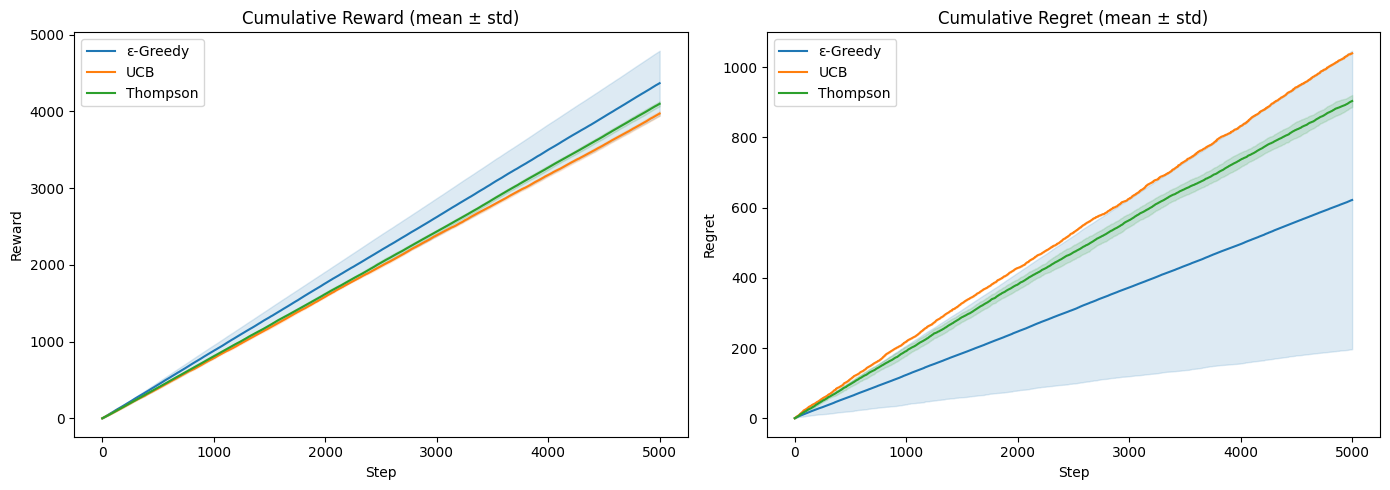

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = range(len(eg_rewards))

for label, rewards, regrets, r_std, reg_std in [
    ("ε-Greedy", eg_rewards, eg_regrets, eg_r_std, eg_reg_std),
    ("UCB",      ucb_rewards, ucb_regrets, ucb_r_std, ucb_reg_std),
    ("Thompson", ts_rewards, ts_regrets, ts_r_std, ts_reg_std),
]:
    line_r   = axes[0].plot(rewards, label=label)[0]
    line_reg = axes[1].plot(regrets, label=label)[0]
    axes[0].fill_between(steps, rewards - r_std, rewards + r_std, alpha=0.15, color=line_r.get_color())
    axes[1].fill_between(steps, regrets - reg_std, regrets + reg_std, alpha=0.15, color=line_reg.get_color())

axes[0].set(title="Cumulative Reward (mean ± std)", xlabel="Step", ylabel="Reward")
axes[0].legend()
axes[1].set(title="Cumulative Regret (mean ± std)", xlabel="Step", ylabel="Regret")
axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
n = len(eg_rewards)

eg_test_hr  = test_hit_rate(EpsilonGreedy,   products, train_df, test_df, epsilon=0.1)
ucb_test_hr = test_hit_rate(UCB,             products, train_df, test_df, c=2.0)
ts_test_hr  = test_hit_rate(ThompsonSampling, products, train_df, test_df)

summary = pd.DataFrame({
    "Policy":          ["ε-Greedy", "UCB", "Thompson Sampling"],
    "Total Reward":    [eg_rewards[-1], ucb_rewards[-1], ts_rewards[-1]],
    "Reward Std":      [eg_r_std[-1], ucb_r_std[-1], ts_r_std[-1]],
    "Total Regret":    [eg_regrets[-1], ucb_regrets[-1], ts_regrets[-1]],
    "Train Hit Rate":  [eg_rewards[-1]/n, ucb_rewards[-1]/n, ts_rewards[-1]/n],
    "Test Hit Rate":   [eg_test_hr, ucb_test_hr, ts_test_hr],
}).round(4)
summary


,Policy,Total Reward,Reward Std,Total Regret,Train Hit Rate,Test Hit Rate
0,ε-Greedy,4367.0,422.9709,621.9205,0.8734,0.8240
1,UCB,3971.2,28.8194,1039.7169,0.7942,1.0000
2,Thompson Sampling,4098.4,31.7843,903.8285,0.8197,0.4015


## Interactive Demo (Online Loop)

This demonstrates the MAB loop in real time using Thompson Sampling. A small subset of products is used. Each round: the system picks a product, you respond with `y` (liked) or `n` (didn't), and the arm's belief updates immediately. Type `q` to stop early.

In [10]:
demo_products = np.random.choice(products, size=20, replace=False)
demo = ThompsonSampling(demo_products)

for r in range(15):
    chosen = demo.select_arm()
    a, b = demo.arms[chosen]
    response = input(f"Round {r+1}: Recommend '{chosen}' (belief: α={a}, β={b}). Liked? (y/n/q): ")

    if response.strip().lower() == "q":
        break

    reward = 1 if response.strip().lower() == "y" else 0
    demo.update(chosen, reward)
    a_new, b_new = demo.arms[chosen]
    print(f"  → Updated: α={a_new}, β={b_new} (expected reward: {a_new/(a_new+b_new):.2f})\n")

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=3 (expected reward: 0.25)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)



## Save MAB Artifacts

Save policy summary and simulation traces for reproducibility.

In [ ]:
mab_dir = project_dir / "artifacts" / "mab"
mab_dir.mkdir(parents=True, exist_ok=True)

summary.to_csv(mab_dir / "mab_policy_summary.csv", index=False)

trace_df = pd.DataFrame({
    "step": np.arange(1, len(eg_rewards) + 1),
    "eg_reward": eg_rewards,
    "eg_regret": eg_regrets,
    "ucb_reward": ucb_rewards,
    "ucb_regret": ucb_regrets,
    "ts_reward": ts_rewards,
    "ts_regret": ts_regrets,
})
trace_df.to_csv(mab_dir / "mab_simulation_trace.csv", index=False)

print("Saved MAB artifacts to:", mab_dir)
print("- mab_policy_summary.csv")
print("- mab_simulation_trace.csv")